# Evaluation of the model

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import tensorflow as tf
from keras import models

In [2]:
model = models.load_model("MNIST_classification_model.keras")

### Make predictions on sample images

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)
1


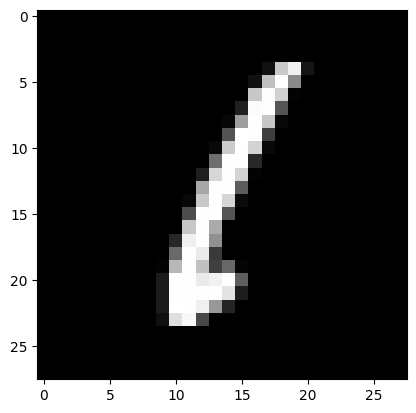

(50000, 784)
(10000, 784)
(10000, 784)


In [3]:
%run -i data_retrieval.ipynb

In [4]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step


Ground truth:  8


Predictions:
Digit: 0 Probability: 5.298120595398359e-05
Digit: 1 Probability: 0.00016741962463129312
Digit: 2 Probability: 0.006799568887799978
Digit: 3 Probability: 0.19332318007946014
Digit: 4 Probability: 5.4879128583706915e-06
Digit: 5 Probability: 0.009281003847718239
Digit: 6 Probability: 1.7153915905510075e-06
Digit: 7 Probability: 2.8664182991633425e-06
Digit: 8 Probability: 0.7777869701385498
Digit: 9 Probability: 0.012578914873301983


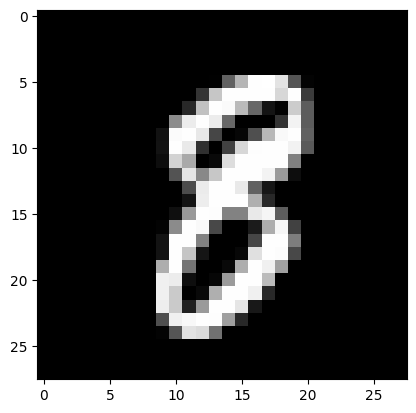

In [6]:
index = 2056
plt.imshow(X_test[index].reshape(28, 28))
print("Ground truth: ", y_test[index])
print("\n")
print("Predictions:")
for i in range(10):
    print(f"Digit: {i} Probability: {predictions[index][i]}")

### Confusion Matrix

In [7]:
predicted_labels = [np.argmax(i) for i in predictions]

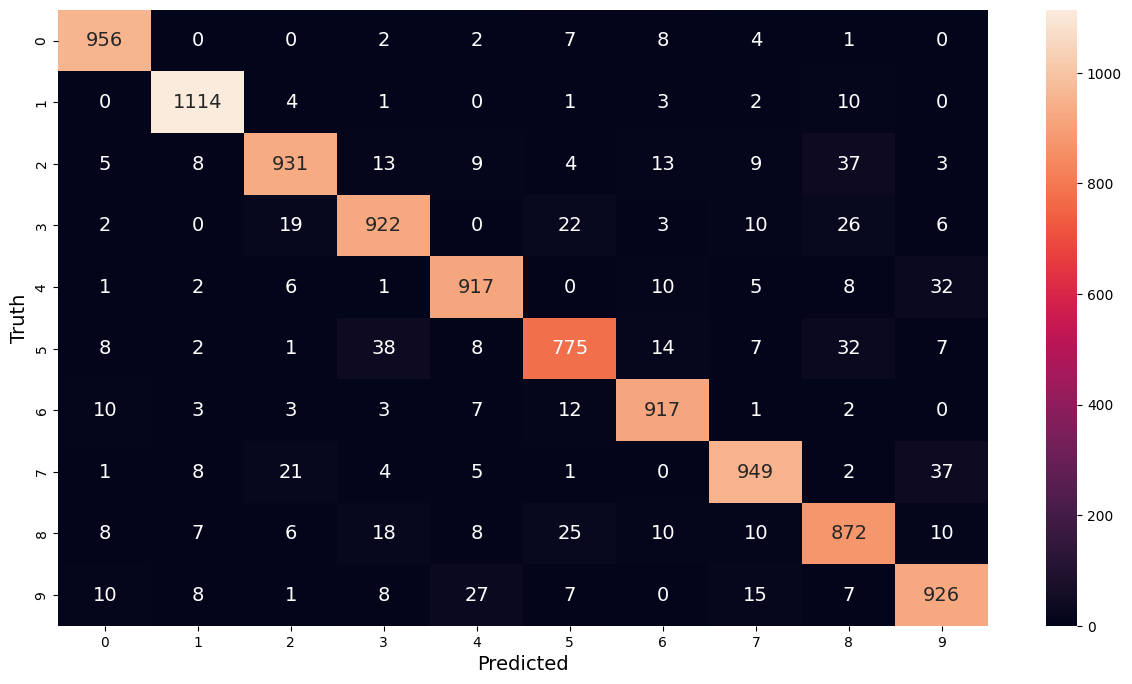

In [8]:
confMatrix = tf.math.confusion_matrix(labels=y_test, predictions=predicted_labels)

plt.figure(figsize=[15, 8])
sn.heatmap(confMatrix, annot=True, fmt="d", annot_kws={"size": 14})
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

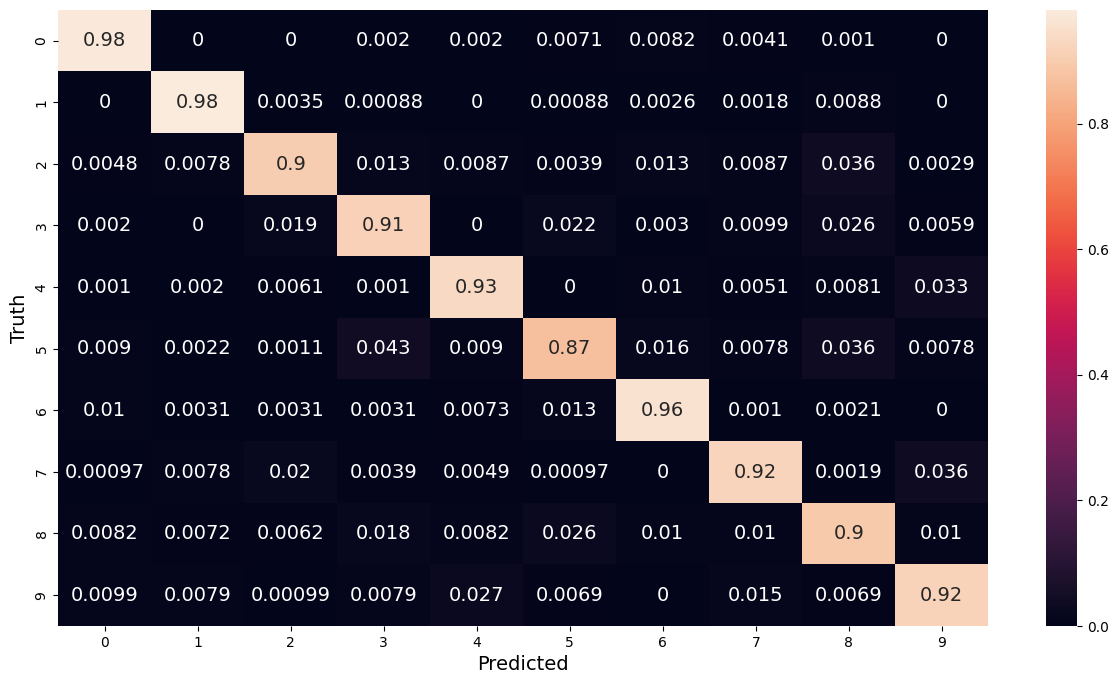

In [9]:
from sklearn.metrics import confusion_matrix

confMatrixNormalised = confusion_matrix(
    y_true=y_test, y_pred=predicted_labels, normalize="true"
)

plt.figure(figsize=[15, 8])
sn.heatmap(confMatrixNormalised, annot=True, annot_kws={"size": 14})
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

### Model Diagnostics: Interpretation of the Weights

We can gain some additional insight as to why the trained weights make sense for detecting each of the nine digits by re-shaping the model weights back into a two-dimensional array. In the plots below, we're displaying the weights for three different neurons corresponding to digits 0, 1 and 2. The dot product between the input image and the weights (plus a bias term) for each of the neurons produces a number which is then converted to a probability via the softmax function.

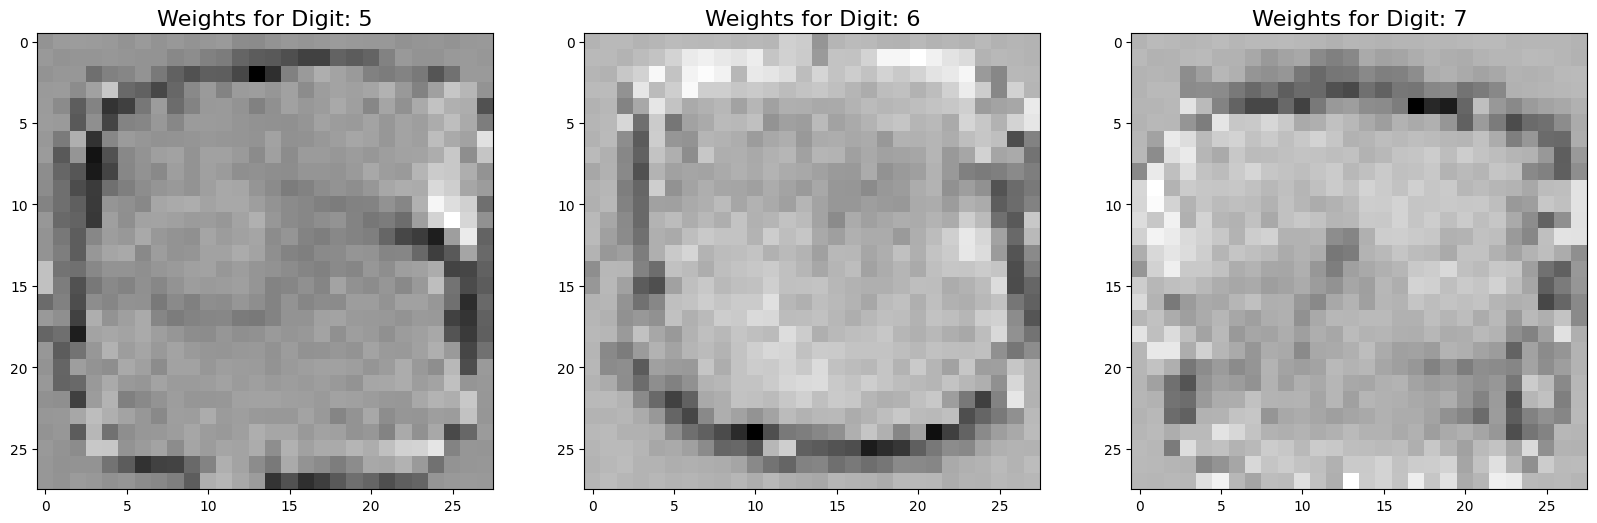

In [10]:
weights = model.layers[0].get_weights()[0]
bias = model.layers[0].get_weights()[1]

weights_0 = weights[:, 5] + bias[5]
weights_0 = np.reshape(weights_0, (28, 28))

weights_1 = weights[:, 6] + bias[6]
weights_1 = np.reshape(weights_1, (28, 28))

weights_2 = weights[:, 7] + bias[7]
weights_2 = np.reshape(weights_2, (28, 28))

plt.figure(figsize=(20, 7))
plt.subplot(131)
plt.title("Weights for Digit: 5")
plt.imshow(weights_0)
plt.subplot(132)
plt.title("Weights for Digit: 6")
plt.imshow(weights_1)
plt.subplot(133)
plt.title("Weights for Digit: 7")
plt.imshow(weights_2)